In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import networkExpansionPy.folds as nf
import networkExpansionPy.lib as ne
import glob
import csv
import json
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from decimal import Decimal
import requests

In [2]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]

    
    return valid_keys, data1, data2

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts', x_range = None):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if not x_range is None:
        plt.xlim([x_range[0], x_range[1]])
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()
    
def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

In [3]:
random = pd.read_pickle('../2023-08-06_19-16-43_random_fold_ordering_14685-fixed-rn-seeds.pkl')

In [455]:
# best at the moment
batm = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-36_no_look_ahead_rules_ignore_versions_3141.pkl')
# batm2 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-54_no_look_ahead_rules_ignore_versions_3142.pkl')

In [5]:
# from folds.py

"""
Attributes:
    iteration (int): The current iteration number.
    cpds (dict): A dictionary containing compounds and what iteration they appear.
    rns (dict): A dictionary containing reactions and what iteration they appear.
    folds (dict): A dictionary containing folds and what iteration they appear.
    rules (dict): A dictionary containing rules and what iteration they appear.
    start_datetime (str): A string representing the start date and time of the run.
    start_time (float): The start time of the run in seconds.
    iteration_time (dict): A dictionary containing iteration times.
    final_path (str): A string representing the path to the final result file.
    temp_path (str): A string representing the path to the temporary result file.
    max_effects (dict): A dictionary containing all possible foldsets which could be injected after each iteration.
    size2foldsets (dict): A dictionary containing remaining foldsets keyed by size after each iteration.

Methods:
    first_update: Updates the object attributes on the first iteration.
    update: Updates the object attributes on any other iteration.
    update_cpds: Updates the cpds attribute.
    update_rns: Updates the rns attribute.
    update_folds: Updates the folds attribute.
    update_rules: Updates the rules attribute.
    update_iteration_time: Updates the iteration_time attribute.
    update_max_effects: Updates the max_effects attribute.
    update_size2foldsets: Updates the size2foldsets attribute.
    update_iter: Updates the iteration attribute.
    get_path: Returns the path to the result file.
    temp_write: Writes temporary results to a file.
    final_write: Writes final results to a file.
"""

'\nAttributes:\n    iteration (int): The current iteration number.\n    cpds (dict): A dictionary containing compounds and what iteration they appear.\n    rns (dict): A dictionary containing reactions and what iteration they appear.\n    folds (dict): A dictionary containing folds and what iteration they appear.\n    rules (dict): A dictionary containing rules and what iteration they appear.\n    start_datetime (str): A string representing the start date and time of the run.\n    start_time (float): The start time of the run in seconds.\n    iteration_time (dict): A dictionary containing iteration times.\n    final_path (str): A string representing the path to the final result file.\n    temp_path (str): A string representing the path to the temporary result file.\n    max_effects (dict): A dictionary containing all possible foldsets which could be injected after each iteration.\n    size2foldsets (dict): A dictionary containing remaining foldsets keyed by size after each iteration.\n

In [8]:
# cumiter = algorithm iteration number
# folditer = fold injection order

## iteration cum

In [9]:
random.iteration_cum

593

In [10]:
batm.iteration_cum

999

## iteration (fold)

In [11]:
random.iteration

399

In [12]:
batm.iteration

371

## cpds_cumiter

4318


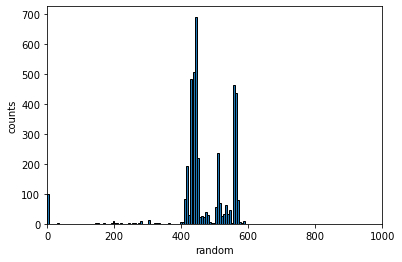

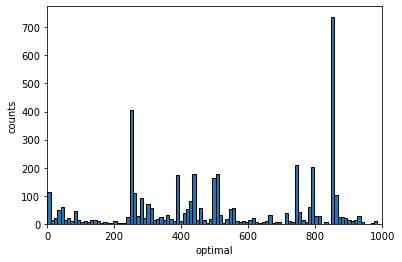

In [13]:
# cpds_cumiter: cmpd vs. iter# when cmpd was discovered

print(len(batm.cpds_cumiter))
histogram(random.cpds_cumiter, bins=100, x_range=[0,1000], x_axis='random')
histogram(batm.cpds_cumiter, bins=100, x_range=[0,1000], x_axis='optimal')

In [14]:
iter2cmpd_random = {}
for c, order in random.cpds_cumiter.items():
    if order not in iter2cmpd_random.keys():
        iter2cmpd_random[order] = [c]
    else:
        iter2cmpd_random[order].append(c)
print(len(iter2cmpd_random))

iter2cmpd = {}
for c, order in batm.cpds_cumiter.items():
    if order not in iter2cmpd.keys():
        iter2cmpd[order] = [c]
    else:
        iter2cmpd[order].append(c)
print(len(iter2cmpd))

197
651


In [15]:
len(iter2cmpd[0])  # seed

80

In [16]:
print(max(random.cpds_cumiter.values()))
print(max(batm.cpds_cumiter.values()))

590
985


In [17]:
iter2cmpdFULL_random = {}
cumm = 0
for i in range(0, max(random.cpds_cumiter.values())): 
    if i in iter2cmpd_random.keys():
        cumm += len(iter2cmpd_random[i])
    iter2cmpdFULL_random[i] = cumm 

iter2cmpdFULL = {}
cumm = 0
for i in range(0, max(batm.cpds_cumiter.values())): 
    if i in iter2cmpd.keys():
        cumm += len(iter2cmpd[i])
    iter2cmpdFULL[i] = cumm

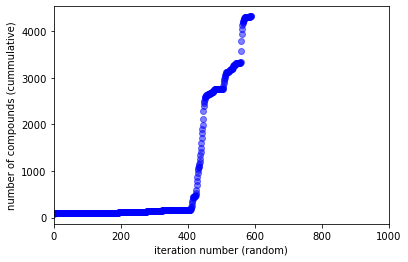

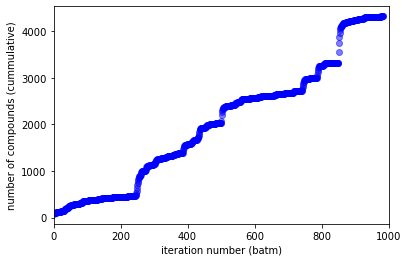

In [18]:
plt.scatter(iter2cmpdFULL_random.keys(), iter2cmpdFULL_random.values(), marker='o', color='b', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('iteration number (random)')
plt.ylabel('number of compounds (cummulative)')
plt.xlim([0, 1000])
# plt.savefig('scatter.png')
plt.show()

plt.scatter(iter2cmpdFULL.keys(), iter2cmpdFULL.values(), marker='o', color='b', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('iteration number (batm)')
plt.ylabel('number of compounds (cummulative)')
plt.xlim([0, 1000])
# plt.savefig('scatter.png')
plt.show()

## cpds_folditer

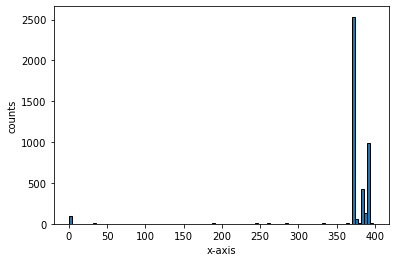

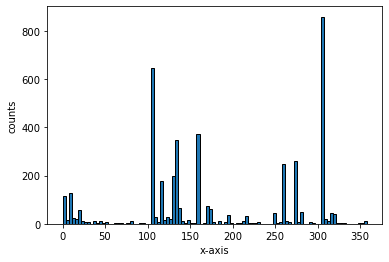

In [19]:
# cpds_folditer: cmpd vs. fold order (0-398) when cmpd was discovered
histogram(random.cpds_folditer, bins=100)
histogram(batm.cpds_folditer, bins=100)

In [20]:
fo2cmpd_random = {}
for c, order in random.cpds_folditer.items():
    if order not in fo2cmpd_random.keys():
        fo2cmpd_random[order] = [c]
    else:
        fo2cmpd_random[order].append(c)
print(len(fo2cmpd_random))

fo2cmpd = {}
for c, order in batm.cpds_folditer.items():
    if order not in fo2cmpd.keys():
        fo2cmpd[order] = [c]
    else:
        fo2cmpd[order].append(c)
print(len(fo2cmpd))

35
173


In [21]:
fo2cmpd_random.keys()

dict_keys([0, 1, 33, 141, 147, 166, 189, 191, 201, 211, 230, 240, 246, 259, 261, 283, 300, 305, 333, 366, 373, 375, 378, 379, 380, 381, 384, 385, 387, 388, 390, 392, 394, 397, 398])

In [22]:
fo2cmpdFULL_random = {}
cumm = 0
for i in range(0, max(random.cpds_folditer.values())): 
    if i in fo2cmpd_random.keys():  # this iter# exists in fo2cmpd_random
        cumm += len(fo2cmpd_random[i])  # add the #cmpds discovered
    fo2cmpdFULL_random[i] = cumm 

fo2cmpdFULL = {}
cumm = 0
for i in range(0, max(batm.cpds_folditer.values())): 
    if i in fo2cmpd.keys():
        cumm += len(fo2cmpd[i])
    fo2cmpdFULL[i] = cumm

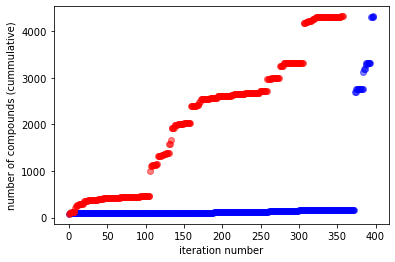

In [23]:
plt.scatter(fo2cmpdFULL_random.keys(), fo2cmpdFULL_random.values(), marker='o', color='b', alpha = 0.5,zorder=2)
plt.scatter(fo2cmpdFULL.keys(), fo2cmpdFULL.values(), marker='o', color='r', alpha = 0.5, zorder=2)
plt.xlabel('iteration number')
plt.ylabel('number of compounds (cummulative)')
plt.show()

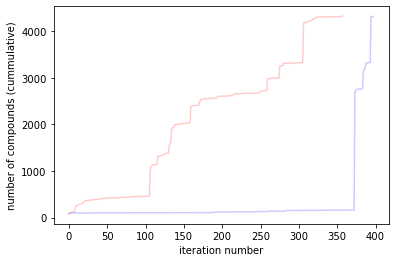

In [24]:
plt.plot(fo2cmpdFULL_random.keys(), fo2cmpdFULL_random.values(), color='b', alpha = 0.2,zorder=2)
plt.plot(fo2cmpdFULL.keys(), fo2cmpdFULL.values(), color='r', alpha = 0.2, zorder=2)
plt.xlabel('iteration number')
plt.ylabel('number of compounds (cummulative)')
plt.show()

## cpds_subiter

In [25]:
# at different (# total folds added), which compounds have been discovered?

In [26]:
random.cpds_subiter.keys()

dict_keys([0, 1, 33, 141, 147, 166, 189, 191, 201, 211, 230, 240, 246, 259, 261, 283, 300, 305, 333, 366, 373, 375, 378, 379, 380, 381, 384, 385, 387, 388, 390, 392, 394, 397, 398])

In [27]:
for key in random.cpds_subiter.keys():
    print(key, ':', len(random.cpds_subiter[key]))

0 : 80
1 : 97
33 : 101
141 : 103
147 : 104
166 : 105
189 : 114
191 : 118
201 : 120
211 : 121
230 : 122
240 : 123
246 : 127
259 : 128
261 : 136
283 : 150
300 : 151
305 : 154
333 : 158
366 : 163
373 : 2699
375 : 2748
378 : 2754
379 : 2755
380 : 2756
381 : 2759
384 : 3122
385 : 3183
387 : 3272
388 : 3318
390 : 3320
392 : 3321
394 : 4304
397 : 4314
398 : 4315


In [28]:
batm.cpds_subiter.keys()

dict_keys([0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 28, 29, 30, 33, 38, 41, 43, 44, 45, 47, 50, 51, 52, 57, 61, 62, 67, 69, 74, 77, 78, 79, 81, 82, 88, 93, 94, 96, 100, 103, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 119, 120, 121, 122, 123, 124, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 137, 138, 140, 142, 143, 144, 145, 147, 148, 150, 153, 155, 156, 159, 160, 161, 163, 167, 170, 172, 174, 177, 180, 183, 184, 185, 190, 192, 193, 194, 196, 199, 201, 205, 207, 208, 210, 211, 212, 213, 214, 215, 218, 219, 224, 227, 230, 234, 249, 250, 251, 255, 257, 259, 262, 264, 266, 267, 275, 276, 278, 280, 282, 292, 293, 295, 297, 302, 306, 307, 309, 311, 312, 316, 317, 318, 320, 321, 322, 323, 324, 326, 327, 329, 330, 332, 349, 354, 355, 357, 358])

In [29]:
for key in batm.cpds_subiter.keys():
    print(key, ':', len(batm.cpds_subiter[key]))

0 : 80
1 : 97
2 : 103
3 : 111
4 : 120
6 : 123
7 : 128
8 : 195
9 : 254
10 : 256
11 : 267
12 : 271
13 : 279
14 : 282
15 : 290
16 : 296
17 : 300
19 : 315
20 : 348
21 : 356
22 : 360
23 : 361
24 : 362
25 : 368
28 : 374
29 : 377
30 : 382
33 : 383
38 : 395
41 : 398
43 : 399
44 : 401
45 : 411
47 : 413
50 : 414
51 : 415
52 : 421
57 : 422
61 : 423
62 : 425
67 : 430
69 : 432
74 : 433
77 : 435
78 : 437
79 : 439
81 : 447
82 : 448
88 : 449
93 : 451
94 : 452
96 : 454
100 : 455
103 : 456
106 : 1004
107 : 1101
108 : 1114
109 : 1120
110 : 1129
111 : 1130
112 : 1134
113 : 1136
114 : 1137
115 : 1147
116 : 1313
117 : 1314
119 : 1321
120 : 1328
121 : 1330
122 : 1331
123 : 1333
124 : 1358
126 : 1370
127 : 1375
128 : 1377
129 : 1380
130 : 1382
131 : 1571
132 : 1577
133 : 1659
134 : 1914
135 : 1923
137 : 1926
138 : 1990
140 : 1991
142 : 1999
143 : 2003
144 : 2004
145 : 2005
147 : 2006
148 : 2007
150 : 2019
153 : 2024
155 : 2027
156 : 2028
159 : 2381
160 : 2393
161 : 2399
163 : 2400
167 : 2403
170 : 2475
172 : 

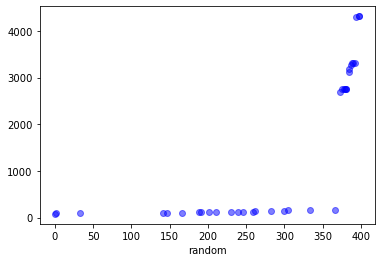

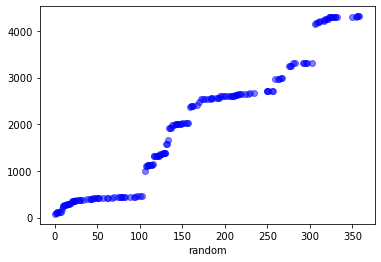

In [30]:
plt.scatter(random.cpds_subiter.keys(), [len(v) for v in random.cpds_subiter.values()], marker='o', color='b', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('random')
# plt.savefig('scatter.png')
plt.show()

plt.scatter(batm.cpds_subiter.keys(), [len(v) for v in batm.cpds_subiter.values()], marker='o', color='b', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('random')
# plt.savefig('scatter.png')
plt.show()

## folds_cumiter

In [31]:
# folds_cumiter: fold vs. iter# when fold was added

In [32]:
iter2fold_random = {}
for c, order in random.folds_cumiter.items():
    if order not in iter2fold_random.keys():
        iter2fold_random[order] = [c]
    else:
        iter2fold_random[order].append(c)
print(len(iter2fold_random))

iter2fold = {}
for c, order in batm.folds_cumiter.items():
    if order not in iter2fold.keys():
        iter2fold[order] = [c]
    else:
        iter2fold[order].append(c)
print(len(iter2fold))

399
371


In [33]:
iter2foldFULL_random = {}
cumm = 0
for i in range(0, max(random.folds_cumiter.values())): 
    if i in iter2fold_random.keys():
        cumm += len(iter2fold_random[i])
    iter2foldFULL_random[i] = cumm 

iter2foldFULL = {}
cumm = 0
for i in range(0, max(batm.folds_cumiter.values())): 
    if i in iter2fold.keys():
        cumm += len(iter2fold[i])
    iter2foldFULL[i] = cumm

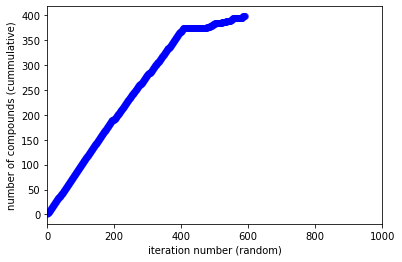

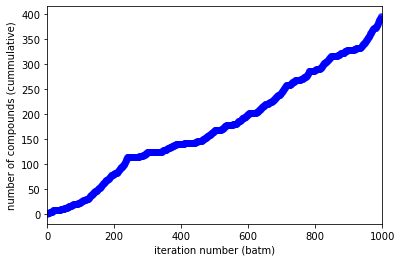

In [34]:
plt.scatter(iter2foldFULL_random.keys(), iter2foldFULL_random.values(), marker='o', color='b', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('iteration number (random)')
plt.ylabel('number of compounds (cummulative)')
plt.xlim([0, 1000])
# plt.savefig('scatter.png')
plt.show()

plt.scatter(iter2foldFULL.keys(), iter2foldFULL.values(), marker='o', color='b', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('iteration number (batm)')
plt.ylabel('number of compounds (cummulative)')
plt.xlim([0, 1000])
# plt.savefig('scatter.png')
plt.show()

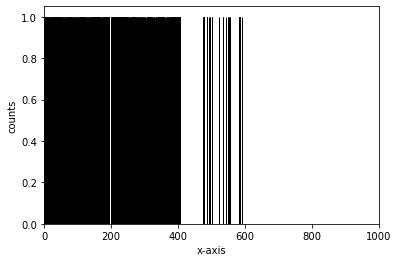

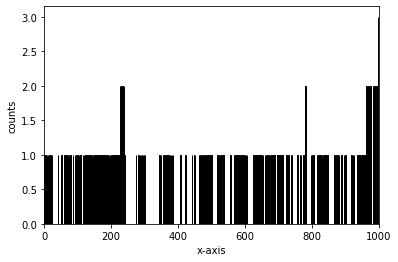

In [35]:
histogram(random.folds_cumiter, bins=1000, x_range=[0,1000])
histogram(batm.folds_cumiter, bins=1000, x_range=[0,1000])

## folds_folditer

In [36]:
# folds_folditer: fold vs. ranked fold order

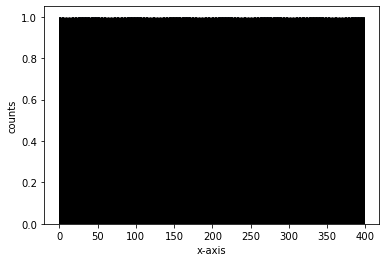

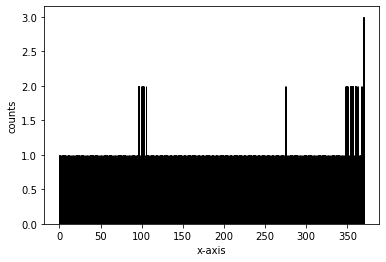

In [37]:
histogram(random.folds_folditer, bins=1000)
histogram(batm.folds_folditer, bins=1000)

## rns_cumiter

In [38]:
len(random.rns_cumiter)

7708

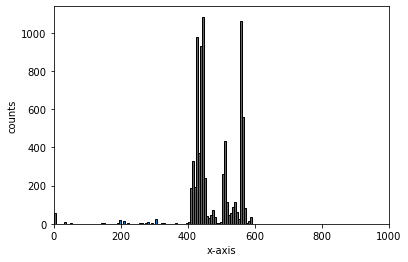

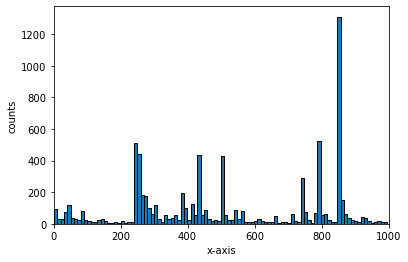

In [39]:
# rns_cumiter: rxn vs. iter# when rxn was discovered

histogram(random.rns_cumiter, bins=100, x_range=[0, 1000])
histogram(batm.rns_cumiter, bins=100, x_range=[0, 1000])

## rns_folditer

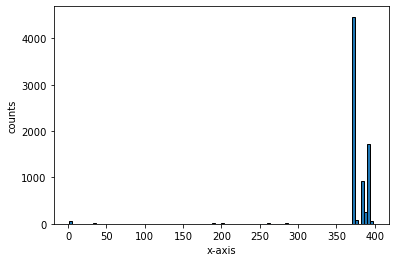

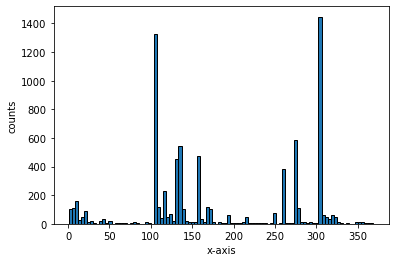

In [40]:
# rns_folditer: rxn vs. fold order when rxn was discovered

histogram(random.rns_folditer, bins=100)
histogram(batm.rns_folditer, bins=100)

## rns_subiter

In [41]:
random.rns_subiter.keys()

dict_keys([1, 33, 47, 141, 147, 166, 189, 191, 201, 211, 226, 230, 240, 246, 259, 261, 275, 283, 297, 300, 305, 333, 366, 373, 374, 375, 376, 378, 379, 380, 381, 383, 384, 385, 387, 388, 390, 392, 393, 394, 396, 397, 398])

In [42]:
batm.rns_subiter.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 28, 29, 30, 33, 34, 36, 38, 39, 41, 42, 43, 44, 45, 47, 50, 51, 52, 55, 57, 58, 61, 62, 65, 67, 69, 71, 74, 76, 77, 78, 79, 81, 82, 87, 88, 92, 93, 94, 96, 99, 100, 103, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 151, 152, 153, 154, 155, 156, 158, 159, 160, 161, 162, 163, 166, 167, 168, 170, 171, 172, 173, 174, 176, 177, 180, 181, 182, 183, 184, 185, 187, 189, 190, 192, 193, 194, 196, 197, 198, 199, 201, 202, 203, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 217, 218, 219, 220, 224, 226, 227, 228, 229, 230, 231, 232, 234, 238, 239, 240, 242, 243, 244, 245, 246, 249, 250, 251, 253, 254, 255, 256, 257, 259, 260, 261, 262, 263, 264, 265, 266, 267, 270, 271, 272, 273, 275, 276, 277, 278, 279, 280, 281, 282, 283

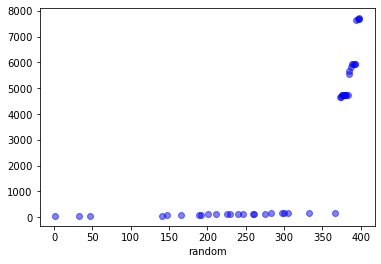

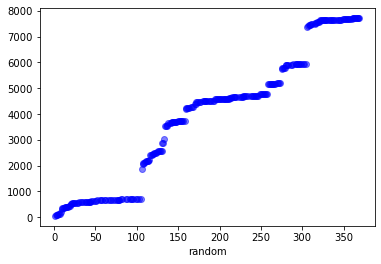

In [43]:
plt.scatter(random.rns_subiter.keys(), [len(v) for v in random.rns_subiter.values()], marker='o', color='b', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('random')
# plt.savefig('scatter.png')
plt.show()

plt.scatter(batm.rns_subiter.keys(), [len(v) for v in batm.rns_subiter.values()], marker='o', color='b', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('random')
# plt.savefig('scatter.png')
plt.show()

## rules_cumiter

7582
7582


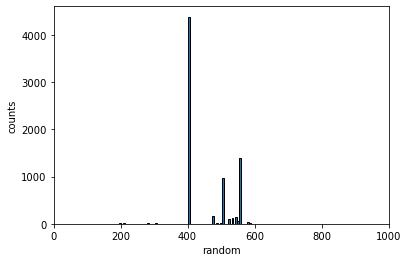

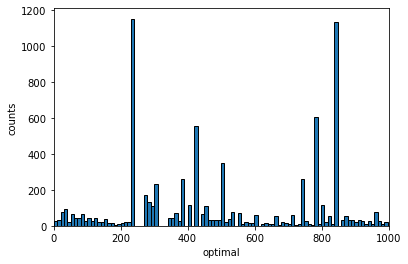

In [44]:
# rules_cumiter: rule vs. iter# when rule was discovered

print(len(random.rules_cumiter))
print(len(batm.rules_cumiter))
histogram(random.rules_cumiter, bins=100, x_range=[0,1000], x_axis='random')
histogram(batm.rules_cumiter, bins=100, x_range=[0,1000], x_axis='optimal')

## rules_folditer

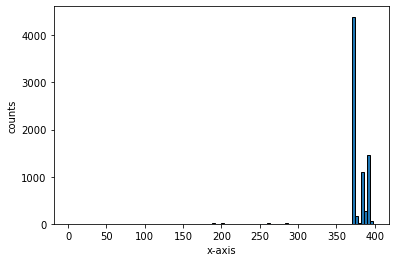

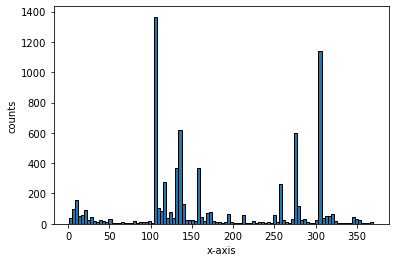

In [45]:
# rules_folditer: rule vs. fold order when rule was discovered

histogram(random.rules_folditer, bins=100)
histogram(batm.rules_folditer, bins=100)